In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

/Users/tobiasmanwaring/Documents/UCL/Repos/Other/trTesting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[*********************100%***********************]  1 of 1 completed


1081 combinations tested


Price,Adj Close,Close,High,Low,Open,Volume,48_ma,49_ma,Strategy,Asset_Returns,Strategy_Returns
1,1.341832,1.341832,1.349164,1.341099,1.341922,0,1.341145,1.341144,-1.0,0.001047,-0.001047
2,1.344086,1.344086,1.345859,1.340249,1.343996,0,1.342166,1.342165,1.0,0.002728,0.000632
3,1.341940,1.341940,1.349801,1.341058,1.341742,0,1.342106,1.342105,1.0,0.001127,-0.000966
4,1.350129,1.350129,1.359712,1.348345,1.350001,0,1.343847,1.343844,1.0,0.007237,0.005131
5,1.366251,1.366251,1.371253,1.364331,1.366251,0,1.347981,1.347969,1.0,0.019264,0.017133
6,1.367746,1.367746,1.379082,1.366512,1.367521,0,1.351169,1.351152,1.0,0.020379,0.018246
7,1.382437,1.382437,1.382935,1.375194,1.382552,0,1.355671,1.355644,1.0,0.031340,0.029183
8,1.382533,1.382533,1.384677,1.374835,1.382342,0,1.359177,1.359142,1.0,0.031411,0.029254
9,1.380643,1.380643,1.381444,1.371479,1.380910,0,1.361748,1.361708,1.0,0.030001,0.027848
10,1.367914,1.367914,1.371441,1.362751,1.368101,0,1.362432,1.362394,1.0,0.020505,0.018371


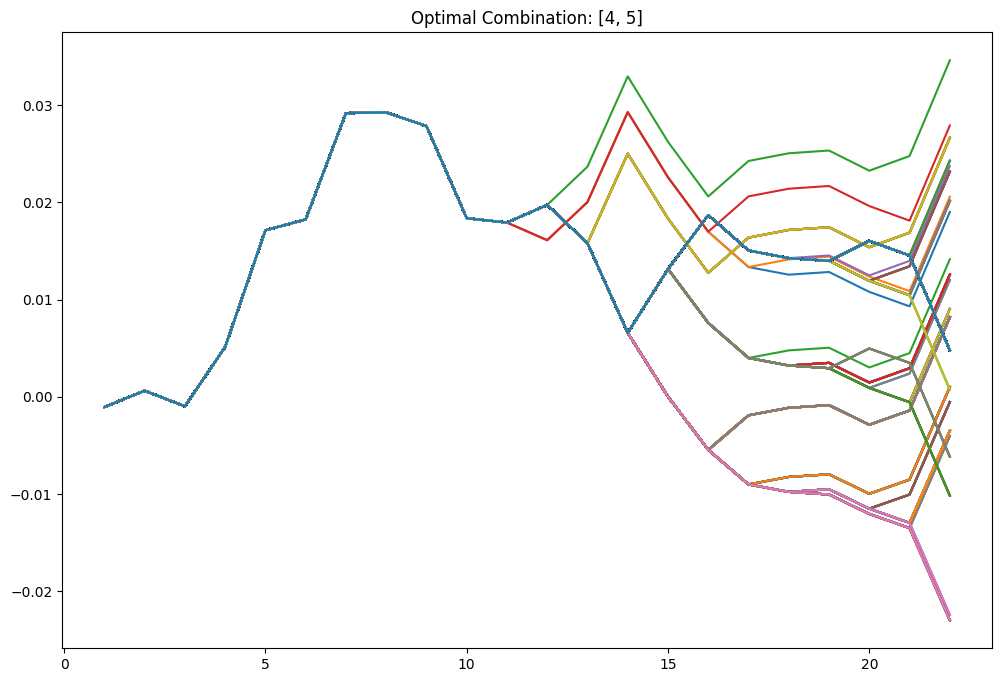

In [2]:
TICKER = 'GBPUSD=X'
INTERVAL='1d'


if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
LOOKBACK = 10000


FAST = list(range(3, 50))
SLOW = list(range(4, 50))


def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]


def add_moving_averages(df, fast, slow):
    df[f'{fast}_ma'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ma'] = df['Close'].ewm(span=slow).mean()

    return df.dropna()


def add_strategy(df, fast, slow):
    df['Strategy'] = np.where(df[f'{fast}_ma'] > df[f'{slow}_ma'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df


def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.plot(df['Strategy_Returns'])    
    return df.dropna()


def main():
    base = get_data()
    plt.figure(figsize=(12, 8))
    legend_list = []

    best_returns = -np.inf
    best_params = None

    count = 0
    for s in SLOW:
        for f in FAST:
            if f < s:
                df = base.copy()
                df = add_moving_averages(df, f, s)
                df = add_strategy(df, f, s)
                df = test_strategy(df)
                legend_list.append(f'{f}, {s} cross')

                returns = float(df['Strategy_Returns'].iloc[-1])
                if returns > best_returns:
                    best_returns = returns
                    best_params = [f, s]
                
                count += 1

    plt.title(f'Optimal Combination: {best_params}')
    print(f'{count} combinations tested')
    return df

main()